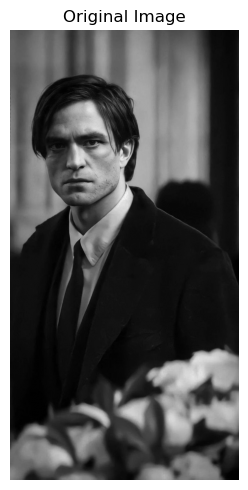

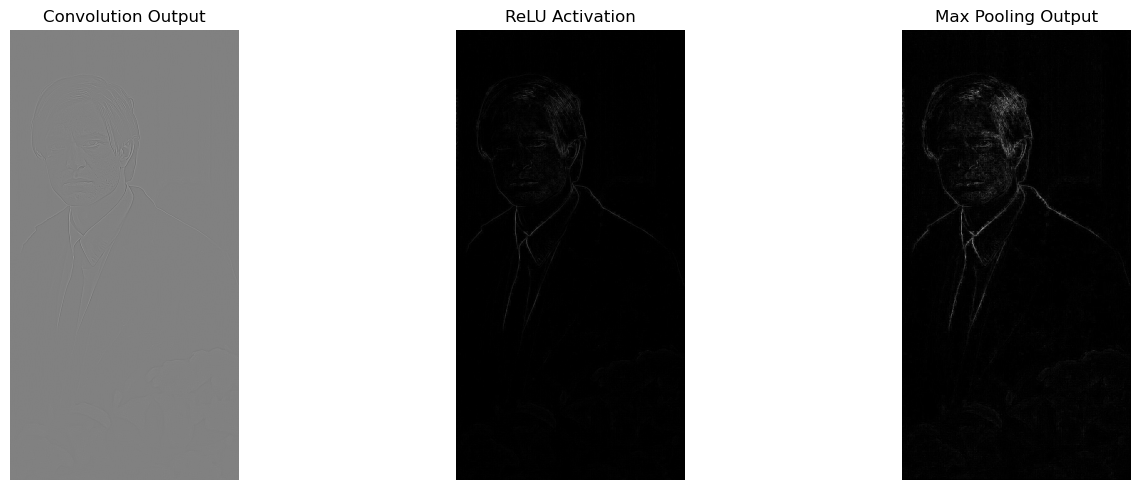

In [11]:
# Implement image edge detection using convolution (Full Image Version)

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Plot settings
plt.rc('figure', autolayout=True)
plt.rc('image', cmap='magma')

# ----------------------------
# Load Image
# ----------------------------
image = plt.imread('image.jpg')

# Convert to grayscale if RGB
if image.ndim == 3:
    image = image.mean(axis=2)

# Display original FULL image
plt.figure(figsize=(5,5))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Original Image')
plt.show()

# ----------------------------
# Define Edge Detection Kernel
# ----------------------------
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# ----------------------------
# Convolution
# ----------------------------
convolution_output = convolve2d(
    image,
    kernel,
    mode='same',
    boundary='symm'
)

# ----------------------------
# ReLU Activation
# ----------------------------
relu_output = np.maximum(0, convolution_output)

# ----------------------------
# Max Pooling (2x2)
# ----------------------------
def max_pool(img, size=2):
    h, w = img.shape
    pooled = np.zeros((h // size, w // size))
    for i in range(0, h - size, size):
        for j in range(0, w - size, size):
            pooled[i // size, j // size] = np.max(
                img[i:i+size, j:j+size]
            )
    return pooled

pooled_output = max_pool(relu_output)

# ----------------------------
# Display Results
# ----------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(convolution_output, cmap='gray')
plt.title('Convolution Output')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(relu_output, cmap='gray')
plt.title('ReLU Activation')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pooled_output, cmap='gray')
plt.title('Max Pooling Output')
plt.axis('off')

plt.show()
